# K-Strategy Panel — Viewer

Analisi interattiva dei risultati prodotti da `iq k-analyze`.

**Non calcola nulla** — legge i file già prodotti dalla CLI:
- `outputs/WFO_T_DEV_RESULTS/classification_*.csv`
- `outputs/WFO_T_DEV_RESULTS/<strategy>/*_results.pkl`

**Flusso:**
```
iq k-analyze --ptf <nome> → classification.csv + _results.pkl
questo JN → carica, filtra, visualizza, esporta
```


In [55]:
%run _bootstrap_dev.ipynb


Runtime dev completato.


## §1 — Configurazione


In [56]:
from pathlib import Path
from datetime import datetime
from IPython.display import display
import plotly.express as px

ROOT        = Path().resolve().parent.parent   # investia-quant/
WFO_DIR     = ROOT / 'outputs' / 'WFO_T_DEV_RESULTS'
EXPORT_DIR  = ROOT / 'outputs' / 'k_panel_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATTERN     = 'classification_*.csv'
FILTER_PROMOTED = 'ALL'       # 'ALL' | 'PROMOTED' | 'FAILED'
SORT_BY         = 'Sharpe'    # 'Sharpe' | 'CAGR%' | 'TotRet%' | 'DSR' | 'MaxDD%'
SORT_ASC        = False
RATIO           = '4:1'

print(f'WFO dir  : {WFO_DIR}')
print(f'Export   : {EXPORT_DIR}')
print(f'Filtro   : {FILTER_PROMOTED} | Sort: {SORT_BY} asc={SORT_ASC}')


WFO dir  : /home/luca/Investia/investia-quant/outputs/WFO_T_DEV_RESULTS
Export   : /home/luca/Investia/investia-quant/outputs/k_panel_exports
Filtro   : ALL | Sort: Sharpe asc=False


## §2 — Classifica


In [61]:
df = load_k_classifications(WFO_DIR, CSV_PATTERN, FILTER_PROMOTED, SORT_BY, SORT_ASC)

print(f'Totale  : {len(df)}')
print(f'Promossi: {(df["Promoted"]=="PASS").sum()}')
print(f'Falliti : {(df["Promoted"]=="FAIL").sum()}')
print()
display(style_k_classification(df))

Totale  : 5
Promossi: 1
Falliti : 4



,Ticker,Strategy,Sharpe,CAGR%,TotRet%,BH_TotRet%,DeltaTotRet%,MaxDD%,BH_DD%,DeltaDD%,DSR,OFC,MC,BH_Beat_Ret,BH_Beat_DD,Promoted
0,AMD,bollinger,1.147,89.6,1610.4,966.4,644.1,52.9,66.0,13.1,1.000,PASS,PASS,PASS,PASS,PASS
1,LLY,bollinger,0.948,36.1,292.9,853.6,-560.7,44.0,33.9,-10.1,1.000,PASS,PASS,FAIL,FAIL,FAIL
2,GOOGL,bollinger,0.942,40.2,348.4,442.6,-94.2,32.6,43.5,10.9,1.000,PASS,PASS,FAIL,PASS,FAIL
3,C,bollinger,0.470,15.7,91.2,119.1,-27.9,56.4,56.4,0.0,1.000,PASS,PASS,FAIL,FAIL,FAIL
4,COF,bollinger,0.243,2.1,9.6,98.9,-89.3,59.7,59.4,-0.3,1.000,PASS,PASS,FAIL,FAIL,FAIL


## §3 — Scatter Sharpe vs TotRet%


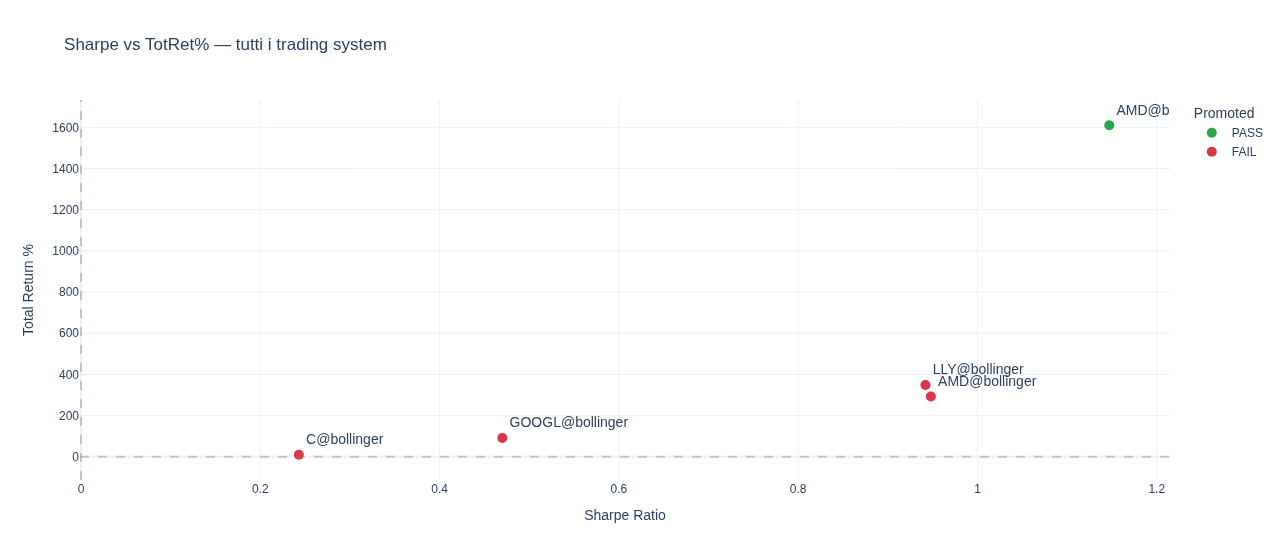

In [54]:
fig = px.scatter(
    df, x='Sharpe', y='TotRet%',
    color='Promoted',
    color_discrete_map={'PASS': '#28a745', 'FAIL': '#dc3545'},
    hover_name=df['Ticker'] + '@' + df['Strategy'],
    hover_data={
        'Sharpe': ':.3f',
        'TotRet%': ':.1f',
        'BH_TotRet%': ':.1f',
        'DeltaTotRet%': ':.1f',
        'MaxDD%': ':.1f',
        'BH_DD%': ':.1f',
        'DeltaDD%': ':.1f',
        'DSR': ':.3f',
        'OFC': True,
        'MC': True,
        'Promoted': True,
    },
    title='Sharpe vs TotRet% — tutti i trading system',
    labels={'Sharpe': 'Sharpe Ratio', 'TotRet%': 'Total Return %'},
    template='plotly_white',
)
fig.update_traces(
    marker_size=10,
    mode='markers+text',
    text=df['Ticker'] + '@' + df['Strategy'],
    textposition='top right',
    textfont=dict(size=14),
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.4)
fig.add_vline(x=0, line_dash='dash', line_color='gray', opacity=0.4)
fig.update_layout(height=560)
fig.show()


## §4 — Equity curve promossi


Promossi: 1


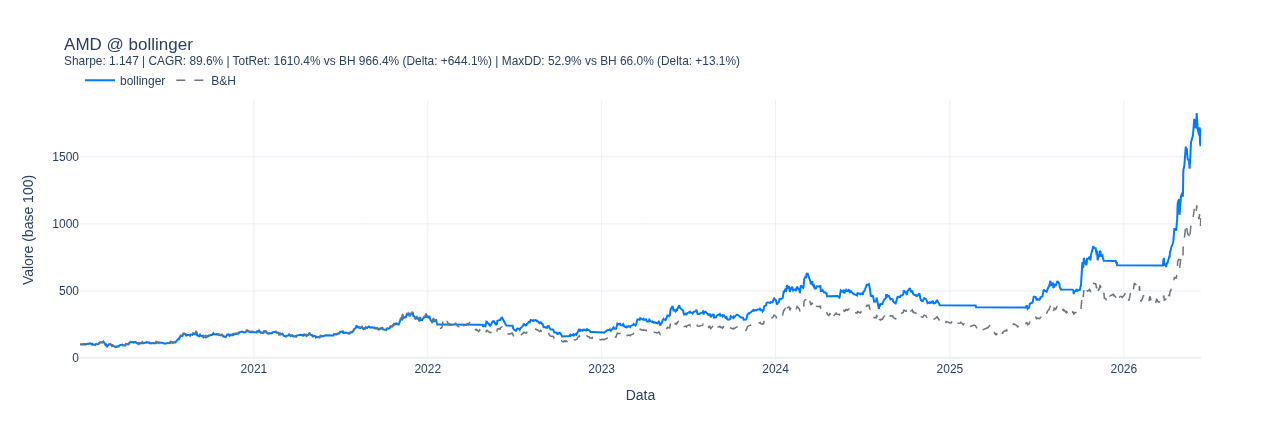

In [49]:
promoted = df[df['Promoted'] == 'PASS']
print(f'Promossi: {len(promoted)}')

for _, row in promoted.iterrows():
    ticker, strategy = row['Ticker'], row['Strategy']
    pf, bh = load_k_equity(WFO_DIR, ticker, strategy, RATIO)
    if pf is None:
        print(f'  {ticker}@{strategy}: pkl non trovato')
        continue
    plot_k_equity(ticker, strategy, pf, bh, row).show()


## §5 — Confronto run


In [50]:
df_all_runs = load_k_classifications(WFO_DIR, CSV_PATTERN, 'ALL', 'Sharpe', False)

if df_all_runs['_run'].nunique() > 1:
    print(f'Run disponibili: {sorted(df_all_runs["_run"].unique())}')
    pivot = df_all_runs.pivot_table(
        index=['Ticker', 'Strategy'], columns='_run',
        values='Sharpe', aggfunc='first'
    ).round(3)
    display(pivot)
else:
    print('Un solo run disponibile.')
    print('Lancia iq k-analyze piu volte per confrontare run diversi.')


Un solo run disponibile.
Lancia iq k-analyze piu volte per confrontare run diversi.


## §6 — Export promossi


In [51]:
promoted = df[df['Promoted'] == 'PASS'].copy()
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# 1. CSV completo promossi
csv_path = EXPORT_DIR / f'promoted_{ts}.csv'
promoted.drop(columns=['_run'], errors='ignore').to_csv(csv_path, index=False)
print(f'CSV salvato: {csv_path}')

# 2. Snippet trading_systems per k_portfolios.py
py_path = EXPORT_DIR / f'trading_systems_{ts}.py'
lines = [
    f'# Generato da k_strategy_panel — {ts}',
    f'# Promossi: {len(promoted)} trading system',
    '',
    'trading_systems = [',
]
for _, row in promoted.iterrows():
    lines.append(
        f'    {{"symbol": "{row["Ticker"]}", "strategy": "{row["Strategy"]}"}},'
        f'  # Sharpe={row["Sharpe"]:.3f}'
        f' TotRet={row["TotRet%"]:.1f}% (BH={row["BH_TotRet%"]:.1f}%)'
        f' MaxDD={row["MaxDD%"]:.1f}% (BH={row["BH_DD%"]:.1f}%)'
    )
lines.append(']')
py_path.write_text('\n'.join(lines))
print(f'Snippet salvato: {py_path}')
print()
print('\n'.join(lines))


CSV salvato: /home/luca/Investia/investia-quant/outputs/k_panel_exports/promoted_20260614_221158.csv
Snippet salvato: /home/luca/Investia/investia-quant/outputs/k_panel_exports/trading_systems_20260614_221158.py

# Generato da k_strategy_panel — 20260614_221158
# Promossi: 1 trading system

trading_systems = [
    {"symbol": "AMD", "strategy": "bollinger"},  # Sharpe=1.147 TotRet=1610.4% (BH=966.4%) MaxDD=52.9% (BH=66.0%)
]
